In [1]:
library(Seurat)
library(ComplexHeatmap)
library(circlize)
library(grid)
packageVersion("ComplexHeatmap")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github pag

[1] ‘2.18.0’

In [2]:
seurat_obj <- readRDS('Nodule_SeuratObject.rds')
seurat_obj

An object of class Seurat 
23482 features across 282 samples within 1 assay 
Active assay: RNA (23482 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [3]:
head(seurat_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,x,y,sample_id,RNA_snn_res.0.6,seurat_clusters,RNA_snn_res.0.4,RNA_snn_res.2,RNA_snn_res.1,RNA_snn_res.1.5,Celltype
,<fct>,<dbl>,<int>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
17700_21000,Lj_6dai_bin50,2760,1558,17700,21000,SS200000124TR_B6_6dai_sec1,8,2,0,1,0,2,Infected_Zone
17750_21300,Lj_6dai_bin50,2906,1645,17750,21300,SS200000124TR_B6_6dai_sec1,0,2,0,4,0,2,Infected_Zone
17800_21250,Lj_6dai_bin50,2487,1392,17800,21250,SS200000124TR_B6_6dai_sec1,5,4,2,2,3,4,Infected_Zone
17850_21300,Lj_6dai_bin50,2505,1433,17850,21300,SS200000124TR_B6_6dai_sec1,5,2,0,5,1,2,Infected_Zone
17900_20650,Lj_6dai_bin50,1639,1051,17900,20650,SS200000124TR_B6_6dai_sec1,2,3,0,7,1,3,Meristems
17950_21000,Lj_6dai_bin50,3144,1785,17950,21000,SS200000124TR_B6_6dai_sec1,8,4,2,2,3,4,Infected_Zone


In [4]:
avg_exp <- as.data.frame(AverageExpression(seurat_obj, group.by = "Celltype")$RNA)

mat <- as.matrix(avg_exp)
mat <- mat[rowSums(mat) > 0, , drop = FALSE]
mat <- mat[apply(mat, 1, sd) > 0, , drop = FALSE]
mat_z <- t(scale(t(mat))) # Row Z-score
mat_z[is.na(mat_z)] <- 0

col_hc <- hclust(dist(t(mat_z)), method = "complete")

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


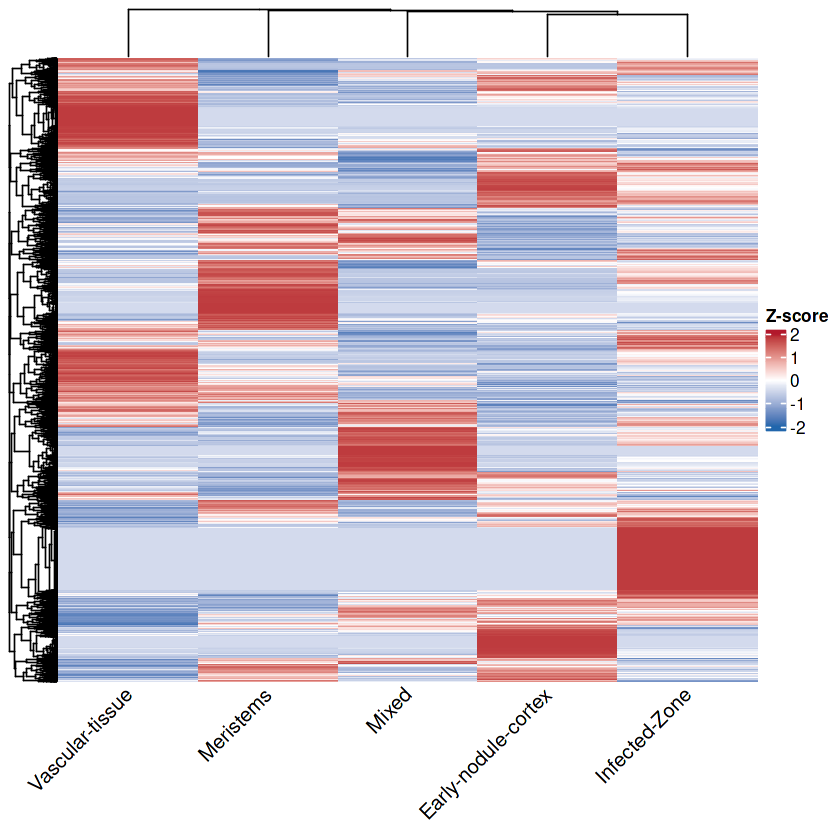

In [5]:
#pdf("avg_expression_Nodule_selected_genes_heatmap_filtered.pdf",6,8)

col_fun <- colorRamp2(c(-2, 0, 2), c("#2166AC", "white", "#B2182B"))

ht <- Heatmap(
  mat_z, name = "Z-score", col = col_fun,
  cluster_columns = as.dendrogram(col_hc), cluster_rows = TRUE,
  show_row_names = FALSE, show_column_names = TRUE, column_names_rot = 45,
  rect_gp = gpar(col = NA)
)

draw(ht)
#dev.off()